# ML_Assignment_1

## Bike Sharing Demand Prediction Challenge

### Student details

* **Name**:_________*Pankaj Singh Rawat*
* **Roll Number**:__*2025ac05533*
* **Course**:_______*BITS M.Tech (AI&ML)*
* **Subject**:______*Machine Learning / ML*
* **Assignment**:___*Assignment 1*

**Objective:** Objective of this assignment is to predict the number of bike rentals per hour using weather, time, and seasonal data.

**Target column:** count (the number of bike rentals per hour)

## Index

*    1. [Exploratory Data Analysis (EDA)](#section_1)
*    2. [Feature Engineering](#section_2)
*    3. [Regression Model](#section_3)
*    4. [Model Comparison and Interpretation](#section_4)
*    5. [Reflection Questions](#section_5)
*    7. [Predictions](#section_6)
*    8. [Conclusion (Q&A)](#section_7)

## Libraries/Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Lasso,Ridge

## Data 

In [2]:
import pandas as pd
pd.set_option('display.max_columns', 50)

train_data = pd.read_csv('bike_train.csv')
train_data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2012-07-15 7:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,17,30,47
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,84,199,283
2,2011-02-06 6:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,0,1,1
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,198,330,531
4,2012-01-09 2:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,2,3,5


#### **About Data**

* **datetime**: Date and time corresponding to each observation. It includes information such as year, month, day, hour, minute, and second.

* **season**: Season during which the observation was recorded.

* **holiday**: Indicates whether the day is a holiday or not.

    - 1 = Holiday

    - 0 = No holiday

* **workingday**: Indicates whether the day is a working day.

    - 1 = Working day

    - 0 = Weekend or holiday

* **weather**: Weather condition during the observation.

* **temp**: Actual temperature in Celsius.

* **atemp**: "Feels like" temperature in Celsius.

* **humidity**: Relative humidity level.

* **windspeed**: Wind speed recorded during the observation.

* **casual**: Number of bike rentals by casual users.

* **registered**: Number of bike rentals by registered users.

* **count**: Total number of bike rentals. This is the target variable to be predicted.

  

## <a id='section_1'>1. Exploratory Data Analysis (EDA)</a>

### Q1. Examine dataset size, missing values, and feature types.

In [3]:
# Check the number of rows and columns
print(train_data.shape)

# Check the data types of each column
print(train_data.dtypes)

# Check for missing values
print(train_data.isnull().sum())

(10450, 12)
datetime          str
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64


### Distribution of target variable (`count`)

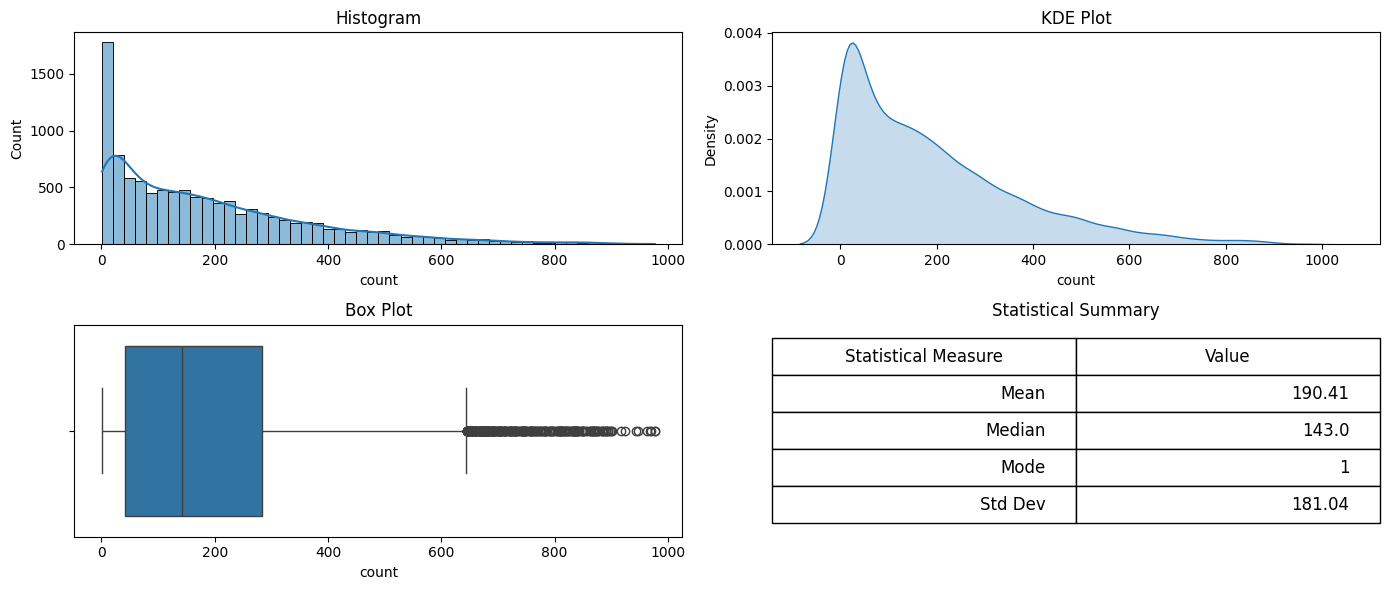

In [4]:
target_col = 'count'
fig, axes = plt.subplots(2, 2, figsize=(14,6))

# Histogram
sns.histplot(train_data[target_col], bins=50, kde=True, ax=axes[0,0])
axes[0,0].set_title('Histogram')

# KDE Plot
sns.kdeplot(train_data[target_col], fill=True, ax=axes[0,1])
axes[0,1].set_title('KDE Plot')

# Box Plot
sns.boxplot(x=train_data[target_col], ax=axes[1,0])
axes[1,0].set_title('Box Plot')

# Statistical summary
axes[1,1].axis('off')

stats_tab = [
    ['Mean', round(train_data[target_col].mean(), 2)],
    ['Median', round(train_data[target_col].median(), 2)],
    ['Mode', round(train_data[target_col].mode()[0], 2)],
    ['Std Dev', round(train_data[target_col].std(), 2)]
]

stats_table = axes[1,1].table(
    cellText=stats_tab,
    colLabels=['Statistical Measure', 'Value'],
    loc='center'
)

stats_table.auto_set_font_size(False)
stats_table.set_fontsize(12)
stats_table.scale(1, 2.2)

axes[1,1].set_title('Statistical Summary')

plt.tight_layout()
plt.show()

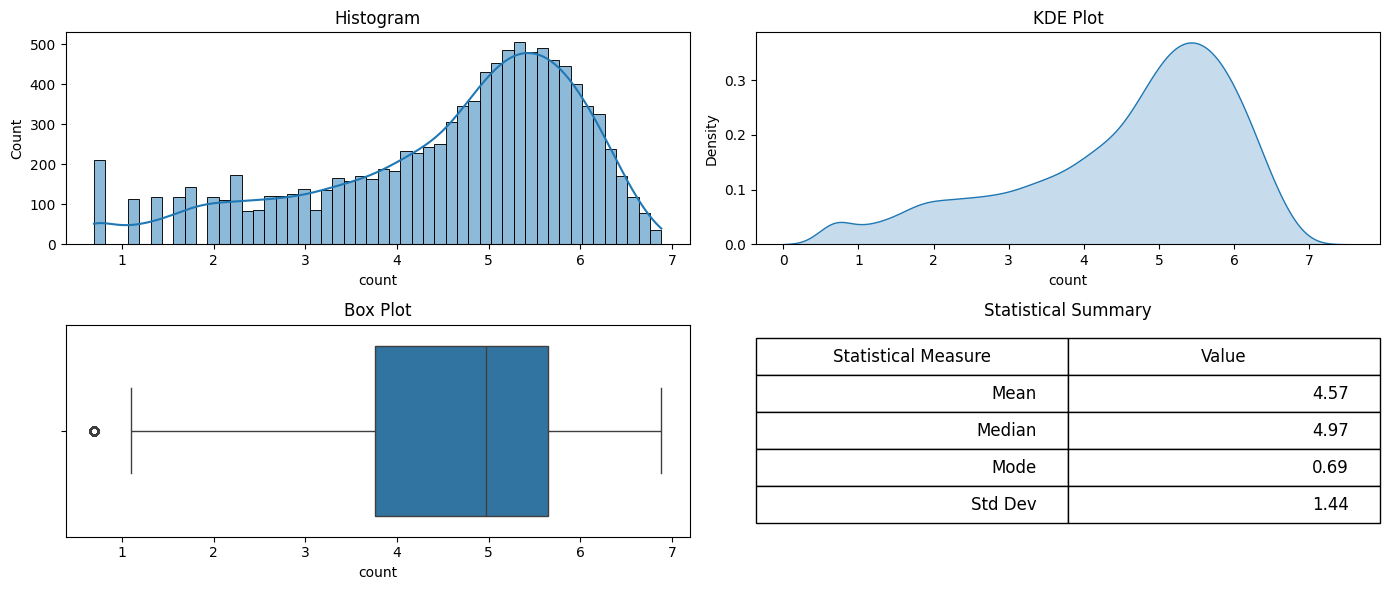

In [5]:
## Applying log transformation to the target variable 'count' to reduce skewness and stabilize variance for better model performance
temp = np.log1p(train_data[target_col])
fig, axes = plt.subplots(2, 2, figsize=(14,6))

# Histogram
sns.histplot(temp, bins=50, kde=True, ax=axes[0,0])
axes[0,0].set_title('Histogram')

# KDE Plot
sns.kdeplot(temp, fill=True, ax=axes[0,1])
axes[0,1].set_title('KDE Plot')

# Box Plot
sns.boxplot(x=temp, ax=axes[1,0])
axes[1,0].set_title('Box Plot')

# Statistical summary
axes[1,1].axis('off')

stats_tab = [
    ['Mean', round(temp.mean(), 2)],
    ['Median', round(temp.median(), 2)],
    ['Mode', round(temp.mode()[0], 2)],
    ['Std Dev', round(temp.std(), 2)]
]

stats_table = axes[1,1].table(
    cellText=stats_tab,
    colLabels=['Statistical Measure', 'Value'],
    loc='center'
)

stats_table.auto_set_font_size(False)
stats_table.set_fontsize(12)
stats_table.scale(1, 2.2)

axes[1,1].set_title('Statistical Summary')

plt.tight_layout()
plt.show()

### Q2. Visualize relationships between key features and the target variable (count). 

### Relationship between categorical columns and target variable (`count`)

*   Use Annova (i.e. f-statistics) for measuring strength of association

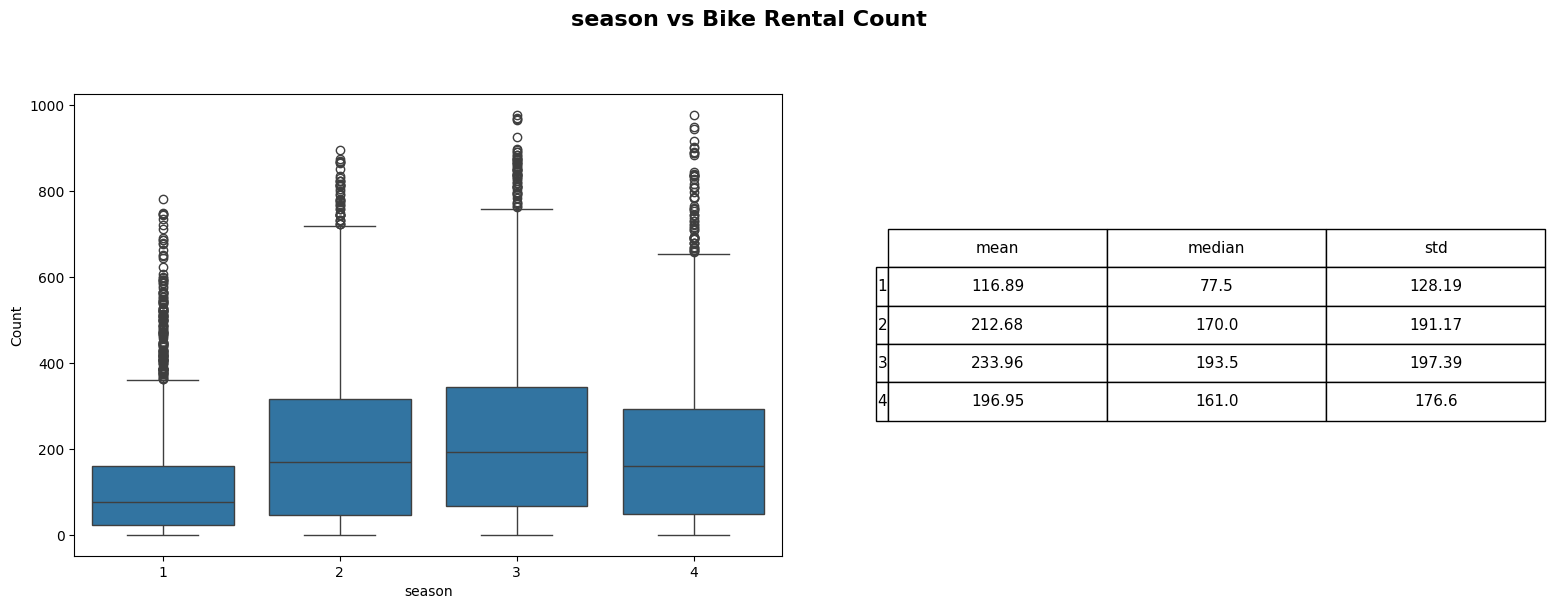

Feature      : season
F-Statistic  : 219.97
P-Value      : 0.0
Association  : Strong



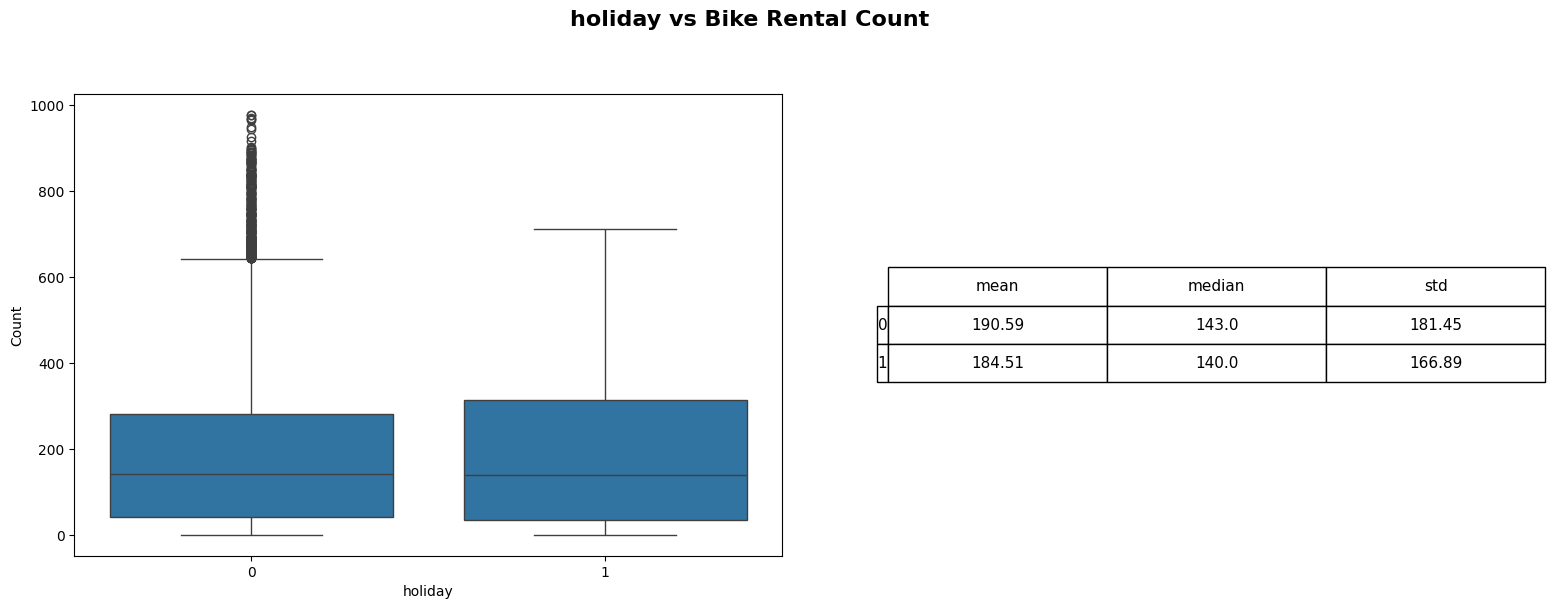

Feature      : holiday
F-Statistic  : 0.33
P-Value      : 0.566027
Association  : Weak



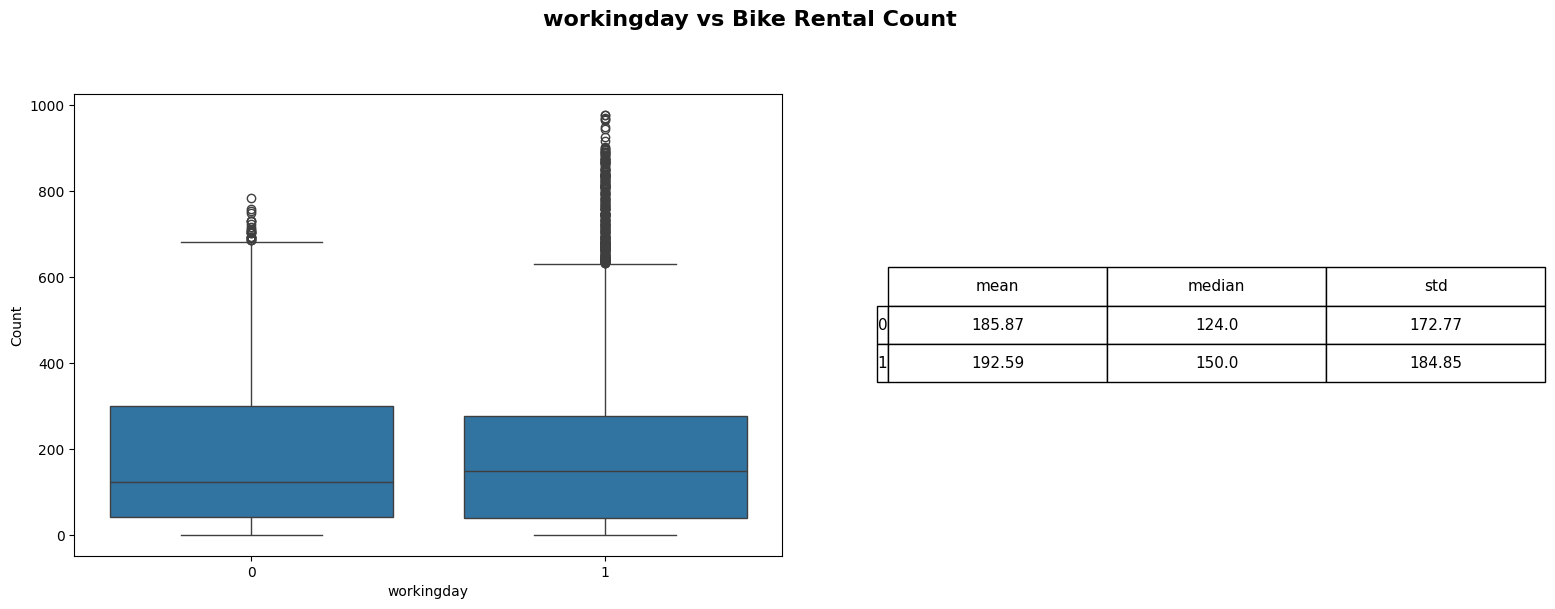

Feature      : workingday
F-Statistic  : 3.15
P-Value      : 0.075955
Association  : Weak



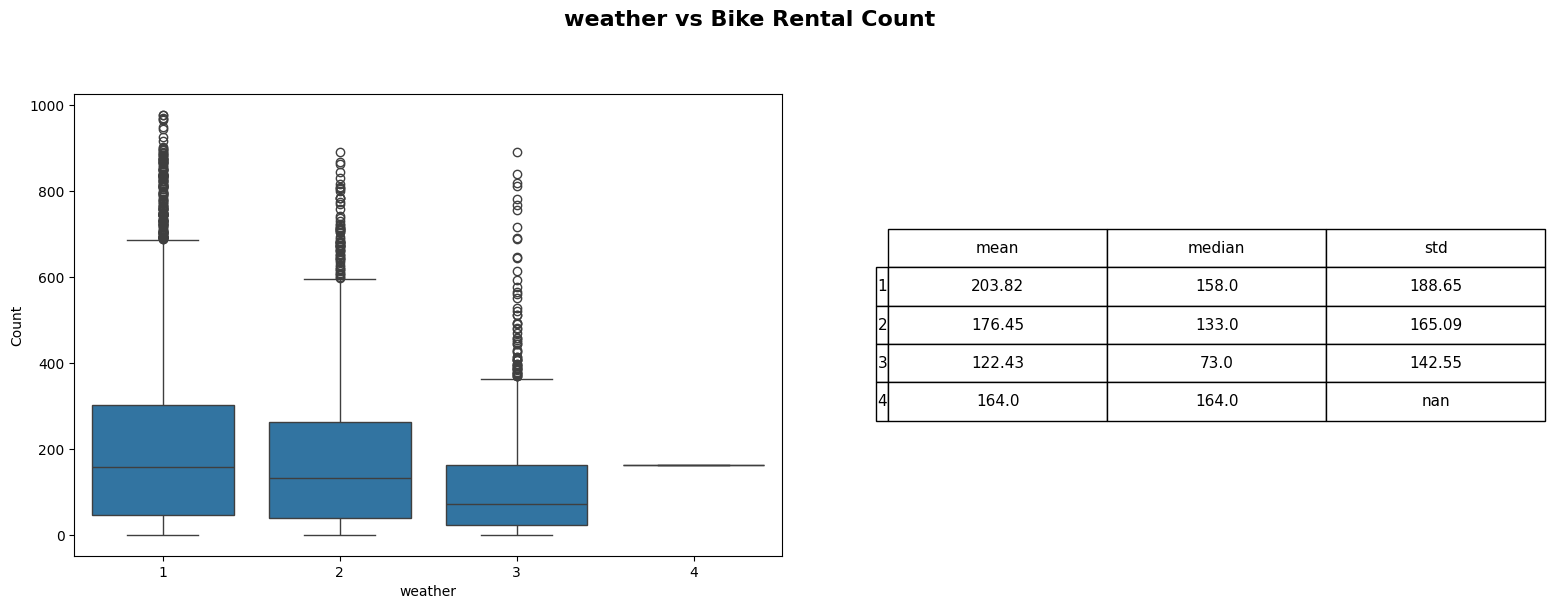

Feature      : weather
F-Statistic  : 57.39
P-Value      : 0.0
Association  : Strong



,Feature,F-Statistic,P-Value,Significance
0,season,219.97,0.000000,Strong
3,weather,57.39,0.000000,Strong
2,workingday,3.15,0.075955,Weak
1,holiday,0.33,0.566027,Weak


In [6]:
cat_cols = ['season', 'holiday', 'workingday', 'weather']
cat_cols_association_results = []

for col in cat_cols:
    fig = plt.figure(figsize=(18,6))

    fig.suptitle(f'{col} vs Bike Rental Count', fontsize=16, fontweight='bold', y=1.02)
    gs = fig.add_gridspec(1, 2, width_ratios=[1.4, 1], wspace=0.3)
    ax1 = fig.add_subplot(gs[0,0])
    ax2 = fig.add_subplot(gs[0,1])

    sns.boxplot(x=col, y=target_col, data=train_data, ax=ax1)
    ax1.set_xlabel(col)
    ax1.set_ylabel('Count')
    ax2.axis('off')
    cat_stats = train_data.groupby(col)[target_col].agg(['mean', 'median', 'std']).round(2)

    cat_stats_table = ax2.table(
        cellText=cat_stats.values,
        rowLabels=cat_stats.index.astype(str),
        colLabels=cat_stats.columns,
        loc='center',
        cellLoc='center',
        rowLoc='center'
    )

    cat_stats_table.auto_set_font_size(False)
    cat_stats_table.set_fontsize(11)

    if len(cat_stats) <= 5:
        cat_stats_table.scale(1.3, 2.3)
    elif len(cat_stats) <= 12:
        cat_stats_table.scale(1.2, 1.9)
    else:
        cat_stats_table.scale(1.15, 1.5)
    plt.show()

    groups = [group[target_col].values for _, group in train_data.groupby(col)]
    f_stat, p_value = f_oneway(*groups)

    cat_cols_association_results.append({
        'Feature': col,
        'F-Statistic': round(f_stat, 2),
        'P-Value': round(p_value, 6),
        'Significance': 'Strong' if p_value < 0.05 else 'Weak'
    })

    print(f'Feature      : {col}')
    print(f'F-Statistic  : {round(f_stat, 2)}')
    print(f'P-Value      : {round(p_value, 6)}')
    print(f'Association  : {"Strong" if p_value < 0.05 else "Weak"}')
    print()

cat_cols_association_df = pd.DataFrame(cat_cols_association_results)
cat_cols_association_df = cat_cols_association_df.sort_values(by='P-Value')
cat_cols_association_df

### Relationship between numerical columns and target variable (`count`)

*   Use Pearson's coefficient for strength of association

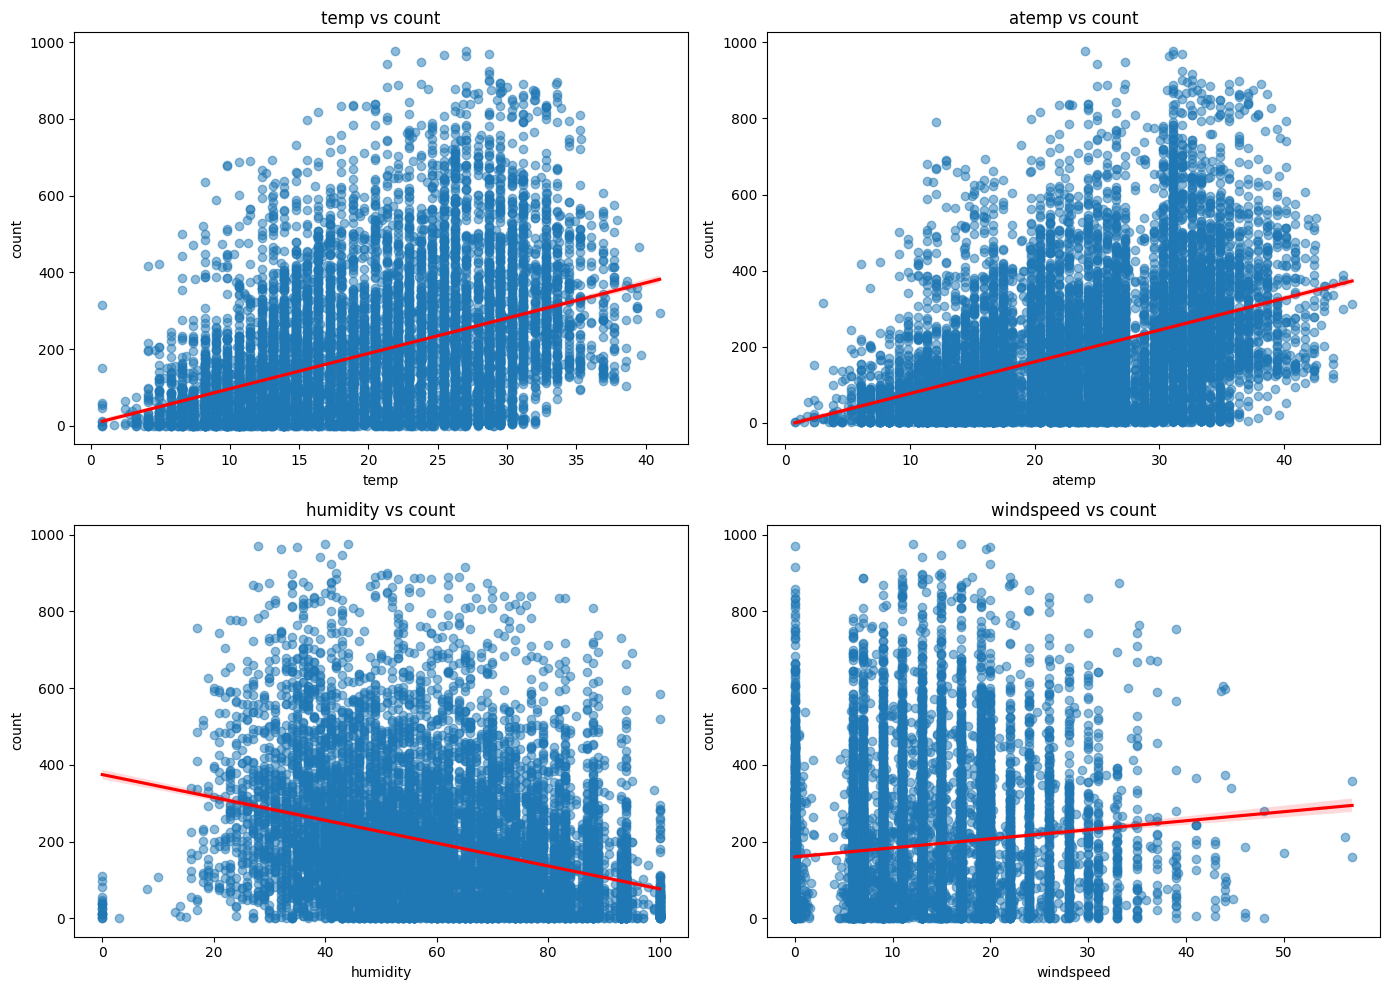

In [7]:
num_cols = ['temp', 'atemp', 'humidity', 'windspeed']

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

num_cols_association_results = []
for i, col in enumerate(num_cols):
    sns.regplot(x=col, y=target_col, data=train_data, scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ax=axes[i])
    axes[i].set_title(f'{col} vs {target_col}')

plt.tight_layout()
plt.show()

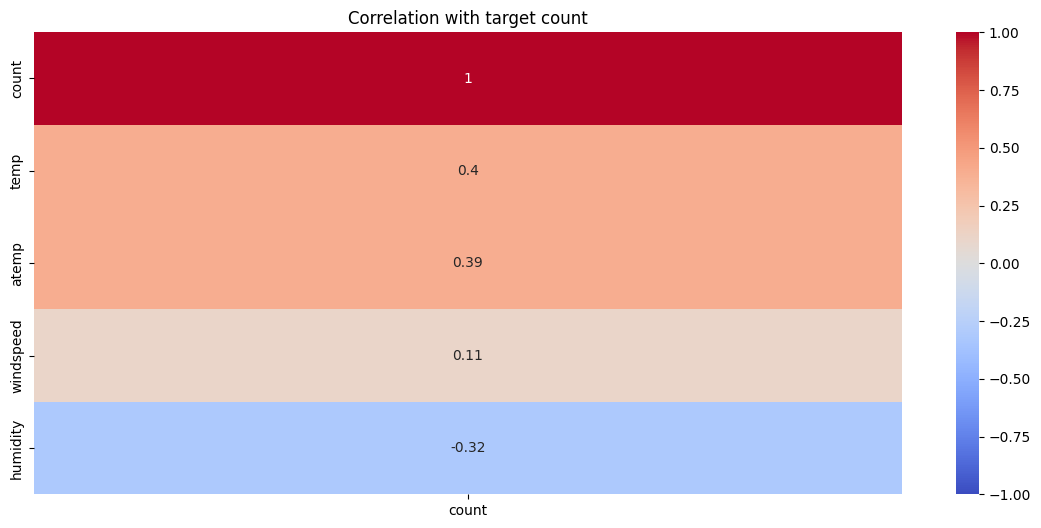

In [8]:
corr_matrix = train_data[num_cols+['count']].corr()
plt.figure(figsize=(14,6))
sns.heatmap(corr_matrix["count"].sort_values(ascending=False).to_frame(),annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation with target count")
plt.show()

### Check correlation among features

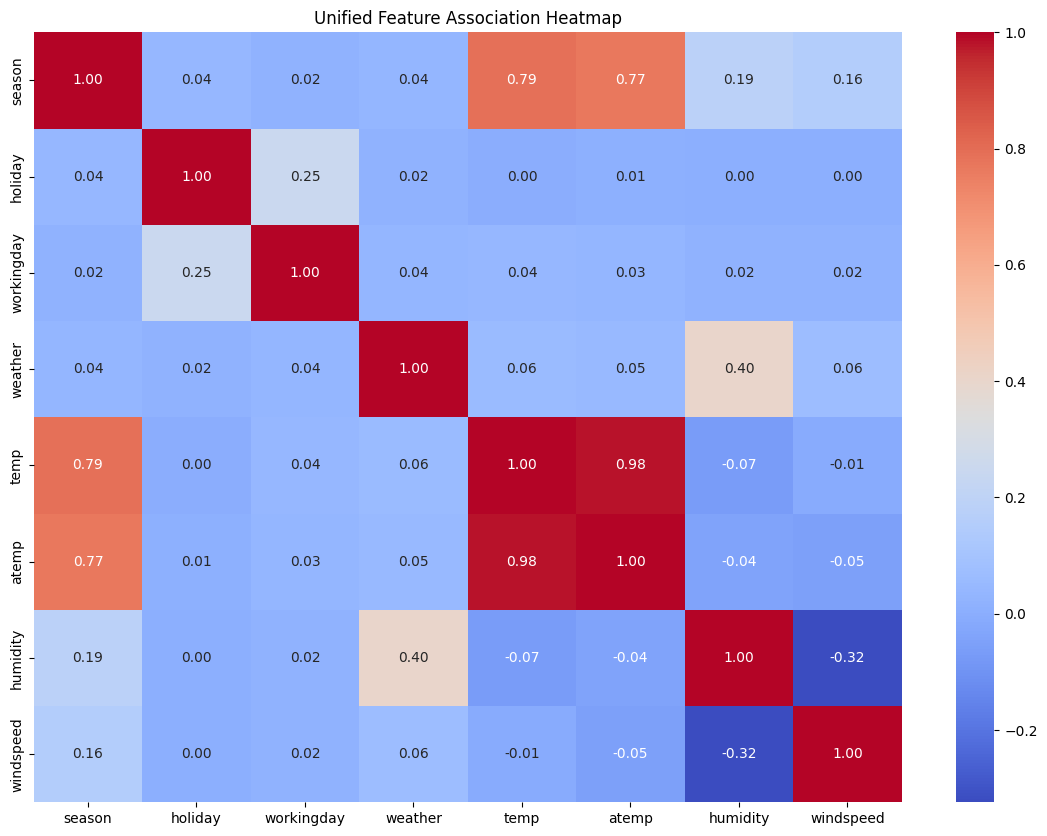

In [9]:
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

def correlation_ratio(categories, measurements):
    categories = pd.Categorical(categories)
    cat_num = categories.codes
    y_avg_array = np.zeros(len(np.unique(cat_num)))
    n_array = np.zeros(len(np.unique(cat_num)))
    for i in range(len(np.unique(cat_num))):
        cat_measures = measurements[cat_num == i]
        n_array[i] = len(cat_measures)
        y_avg_array[i] = np.mean(cat_measures)
    y_total_avg = np.sum(y_avg_array * n_array) / np.sum(n_array)
    numerator = np.sum(n_array * (y_avg_array - y_total_avg) ** 2)
    denominator = np.sum((measurements - y_total_avg) ** 2)

    return np.sqrt(numerator / denominator)

all_cols = cat_cols + num_cols
assoc_matrix = pd.DataFrame(np.zeros((len(all_cols), len(all_cols))), index=all_cols, columns=all_cols)

for col1 in all_cols:
    for col2 in all_cols:
        if col1 in num_cols and col2 in num_cols:
            assoc = train_data[col1].corr(train_data[col2])
        elif col1 in cat_cols and col2 in cat_cols:
            assoc = cramers_v(train_data[col1], train_data[col2])
        elif col1 in cat_cols and col2 in num_cols:
            assoc = correlation_ratio(
                train_data[col1],
                train_data[col2]
            )
        else:
            assoc = correlation_ratio(
                train_data[col2],
                train_data[col1]
            )

        assoc_matrix.loc[col1, col2] = assoc

plt.figure(figsize=(14,10))
sns.heatmap(assoc_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Unified Feature Association Heatmap')
plt.show()

### Key observations of EDA

**Ans3.**

- Temperature-related variables (`temp` and `atemp`) show the strongest positive association with bike rental demand.
- Humidity shows a negative relationship with bike rentals, indicating that higher humidity generally reduces demand.
- ANOVA results suggest that categorical variables such as `season`, `weather`, and `workingday` have statistically significant relationships with bike rental demand.
- Hourly rental demand exhibits clear cyclical patterns, with higher rentals during commuting and daytime hours.
- Seasonal and weather-related factors strongly influence bike-sharing usage and are expected to be among the most informative predictors.
- Therefore, temperature, weather, seasonality, humidity, and time-based features are likely to contribute the most to model performance.


## [2. Feature Engineering](#section_2)

In [10]:
train_data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2012-07-15 7:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,17,30,47
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,84,199,283
2,2011-02-06 6:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,0,1,1
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,198,330,531
4,2012-01-09 2:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,2,3,5


In [11]:
def feature_engineering(df):
    ## Make copy of dataframe to avoid modifying original data
    df = df.copy()

    ## Remove 'casual' and 'registered' columns if they exist, as they are components of the target variable 'count' and would lead to data leakage
    if 'casual' in df.columns:
        df = df.drop(columns=['casual'])
    if 'registered' in df.columns:
        df = df.drop(columns=['registered'])
    # ## Remove atemp column if it exists, as it is highly correlated with temp and can lead to multicollinearity issues in regression models
    # if 'atemp' in df.columns:
    #     df = df.drop(columns=['atemp'])
    ## Remove temp column if it exists, as it is highly correlated with atemp and can lead to multicollinearity issues in regression models
    if 'temp' in df.columns:
        df = df.drop(columns=['temp'])
    ## Create cyclical features for 'hour' and 'month' to capture their periodic nature and improve model performance using datetime information
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['month'] = df['datetime'].dt.month
    df['hour'] = df['datetime'].dt.hour
    df = df.drop(columns=['datetime'])
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df = df.drop(columns=['hour'])
    ## Create cyclical features for 'month' to capture its periodic nature and improve model performance
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df = df.drop(columns=['month'])
    # df = pd.get_dummies(df, columns=['season','weather'], drop_first=True, dtype='float32')
    df = pd.get_dummies(df, columns=['season','weather'], dtype='float32')

    if 'count' in df.columns:
        df['count'] = np.log1p(df['count'])

    df = df.astype('float32')

    return df

In [12]:
train_data = feature_engineering(train_data)
train_data.head()

,holiday,workingday,atemp,humidity,windspeed,count,hour_sin,hour_cos,month_sin,month_cos,season_1,season_2,season_3,season_4,weather_1,weather_2,weather_3,weather_4
0,0.0,0.0,33.334999,79.0,6.003200,3.871201,0.965926,-2.588190e-01,-0.500000,-0.866025,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,37.880001,46.0,15.001300,5.648974,-0.707107,-7.071068e-01,-0.866025,-0.500000,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,12.880000,60.0,15.001300,0.693147,1.000000,6.123234e-17,0.866025,0.500000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,30.566166,61.0,9.512288,6.276643,-0.965926,-2.588190e-01,0.500000,-0.866025,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,12.120000,56.0,8.998100,1.791759,0.500000,8.660254e-01,0.500000,0.866025,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### Key points of feature engineering:

**Ans4.**

1. Removed `casual` and `registered` to prevent target leakage because `count = casual + registered`.
2. Removed one of the highly correlated temperature variables (`temp` or `atemp`) to reduce multicollinearity.
3. Extracted temporal information from `datetime`.
4. Created cyclical transformations (`hour_sin`, `hour_cos`) to capture daily rental patterns.
5. Created cyclical transformations (`month_sin`, `month_cos`) to capture seasonal patterns.
6. Applied one-hot encoding to categorical variables where appropriate.
7. Applied log transformation to the target variable using `log1p()` to reduce skewness and stabilize variance.
8. Converted data types to `float32` for efficient memory usage.

These transformations improved the ability of linear models to capture nonlinear temporal and seasonal patterns in bike rental demand.


## <a id='section_3'>3. Regression Models</a>

### Evaluation Matrix (RMSLE: Root Mean Square Logarthmic Errors)

*   Create a generic evaluation function which gives value of rmsle and show residuals

        def rmsle(y_true, y_pred): 
            return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

In [13]:
## Define RRMSLE evaluation metric for regression performance assessment
def rmsle(y_true, y_pred): 
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

## Function to visualize residuals for regression model to analyze prediction errors and identify any patterns or heteroscedasticity issues
def plot_model_reiduals(model, X_val, y_val, model_name):
    val_pred_log = model.predict(X_val)
    val_pred = np.expm1(val_pred_log)
    y_val_actual = np.expm1(y_val)
    val_pred = np.maximum(val_pred, 0)
    residuals = y_val_actual - val_pred

    plt.figure(figsize=(7,5))
    sns.histplot(residuals, kde=True)
    plt.title(f'{model_name} Residual Distribution')
    plt.xlabel('Residuals')
    plt.show()

## Define a generic function to evaluate regression model using RMSLE metric and visualize residual distribution
def evaluate_model(model, X_train, X_val, y_train, y_val, model_name):

    ## Training the model on training data
    model.fit(X_train, y_train)
    ## Generate predictions on both training and validation sets
    train_pred_log = model.predict(X_train)
    val_pred_log = model.predict(X_val)
    ## Re-transform to normal scale for performance evaluation and residual analysis
    train_pred = np.expm1(train_pred_log)
    val_pred = np.expm1(val_pred_log)
    y_train_actual = np.expm1(y_train)
    y_val_actual = np.expm1(y_val)
    ## Ensure predictions are non-negative since count cannot be negative
    train_pred = np.maximum(train_pred, 0)
    val_pred = np.maximum(val_pred, 0)
    ## Calculate RMSLE for both training and validation sets
    train_rmsle = rmsle(y_train_actual, train_pred)
    val_rmsle = rmsle(y_val_actual, val_pred)

    print(f'{model_name} Performance')
    print('-' * 50)
    print(f'Train RMSLE      : {round(train_rmsle, 4)}')
    print(f'Validation RMSLE : {round(val_rmsle, 4)}')

    plot_model_reiduals(model, X_val, y_val, model_name)

    return {
        'Model': model_name,
        'Train RMSLE': round(train_rmsle, 4),
        'Validation RMSLE': round(val_rmsle, 4)
    }

### Q5. Split data into training and validation sets and build a simple Linear Regression model. 
### Q6. To improve model performance, you may try to: 
*   Extend feature space using polynomial transformations (degree 2 or 3) 
*   Apply Ridge and Lasso regression on polynomial features, Tune the regularization strength (α). 

In [14]:
## Split dataset into features and target variable
X = train_data.drop(columns=['count'])
y = train_data['count']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=24)
print(f'Training set size: {X_train.shape[0]} samples')
print(f'Validation set size: {X_val.shape[0]} samples')

## Store results of model evaluation in a list for comparison
results = []
## StandardScaler is used to standardize features so that all variables have mean = 0 and standard deviation = 1
## This prevents features with larger magnitudes (e.g., humidity) from dominating features with smaller magnitudes (e.g., hour_sin)
## Scaling is especially important for Polynomial Regression, Ridge, and Lasso because regularization and polynomial expansion are sensitive to feature scales

Training set size: 8360 samples
Validation set size: 2090 samples


Simple Linear Regression Performance
--------------------------------------------------
Train RMSLE      : 0.9194999933242798
Validation RMSLE : 0.9460999965667725


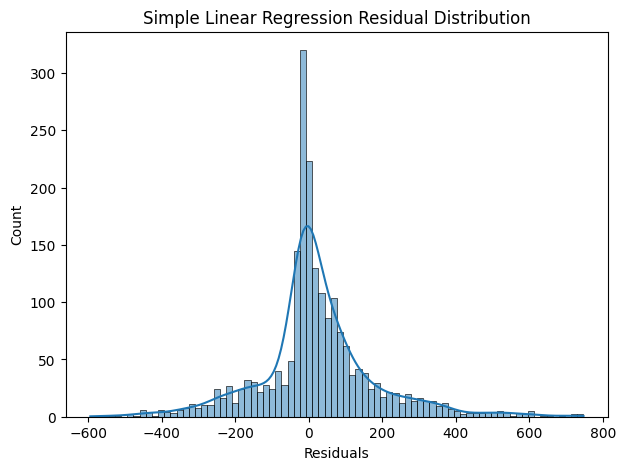

In [15]:
## Simple Linear Regression Model

linear_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

linear_result = evaluate_model(
    linear_model,
    X_train,
    X_val,
    y_train,
    y_val,
    'Simple Linear Regression'
)

results.append(linear_result)

Polynomial Regression Degree 2 Performance
--------------------------------------------------
Train RMSLE      : 0.7142000198364258
Validation RMSLE : 0.7269999980926514


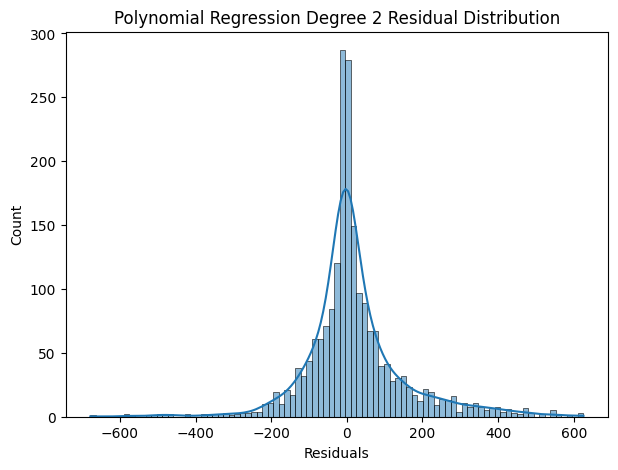

In [16]:
## Polynomial Regression Degree 2 Model

poly2_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

poly2_result = evaluate_model(
    poly2_model,
    X_train,
    X_val,
    y_train,
    y_val,
    'Polynomial Regression Degree 2'
)

results.append(poly2_result)

Polynomial Regression Degree 3 Performance
--------------------------------------------------
Train RMSLE      : 0.504800021648407
Validation RMSLE : 0.5404999852180481


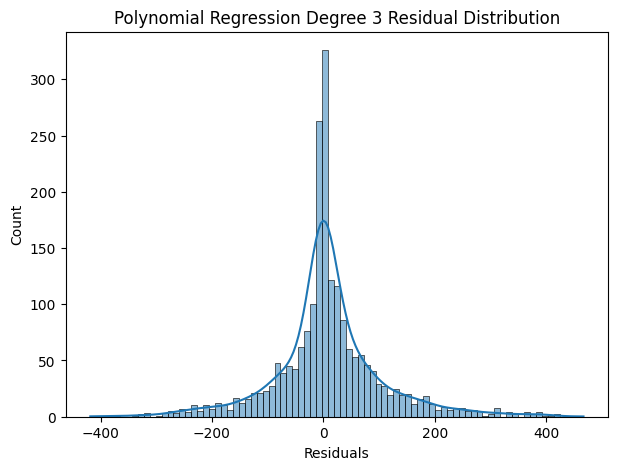

In [17]:
## Polynomial Regression Degree 3 Model

poly3_model = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

poly3_result = evaluate_model(
    poly3_model,
    X_train,
    X_val,
    y_train,
    y_val,
    'Polynomial Regression Degree 3'
)

results.append(poly3_result)

/Users/jordi/DevRoot/projects/ML_Assignment_1/env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.546e+00, tolerance: 1.400e+00
  model = cd_fast.enet_coordinate_descent(
/Users/jordi/DevRoot/projects/ML_Assignment_1/env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.427e+00, tolerance: 1.374e+00
  model = cd_fast.enet_coordinate_descent(
/Users/jordi/DevRoot/projects/ML_Assignment_1/env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterati

Best Parameters: {'model__alpha': 0.0001, 'poly__degree': 3}
Lasso Regression Performance
--------------------------------------------------
Train RMSLE      : 0.5074999928474426
Validation RMSLE : 0.5343999862670898


/Users/jordi/DevRoot/projects/ML_Assignment_1/env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.679e+01, tolerance: 1.732e+00
  model = cd_fast.enet_coordinate_descent(


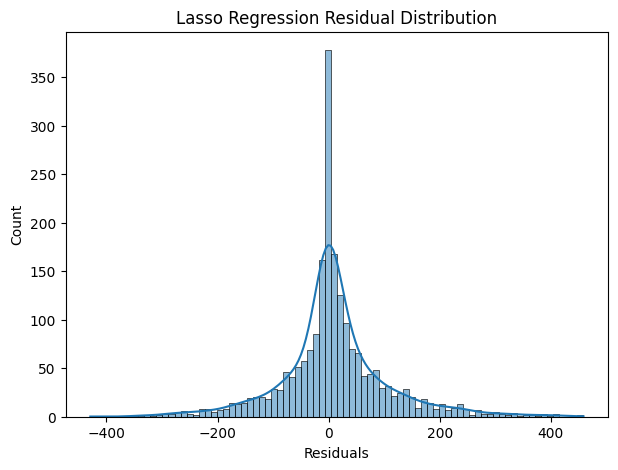

In [18]:
## Lasso Regression with Hyperparameter Tuning (alpha regularization strength and polynomial degree)

lasso_pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', Lasso(max_iter=10000))
])

lasso_param_grid = {
    'poly__degree': [2, 3],
    'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1000000
)

lasso_grid.fit(X_train, y_train)

print('Best Parameters:', lasso_grid.best_params_)

lasso_result = evaluate_model(
    lasso_grid.best_estimator_,
    X_train,
    X_val,
    y_train,
    y_val,
    'Lasso Regression'
)

results.append(lasso_result)

Best Parameters: {'model__alpha': 10, 'poly__degree': 3}
Ridge Regression Performance
--------------------------------------------------
Train RMSLE      : 0.5080999732017517
Validation RMSLE : 0.5364999771118164


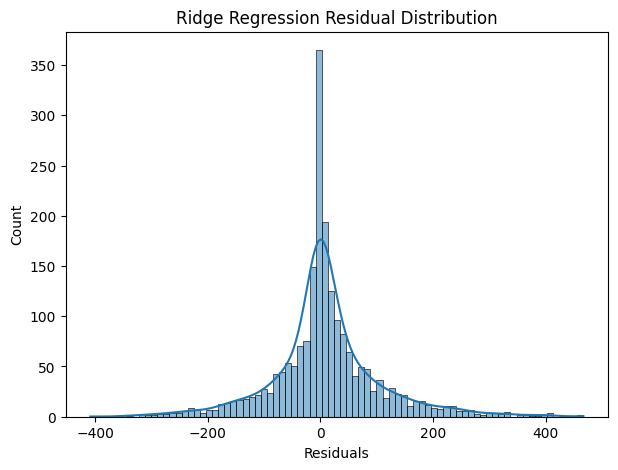

In [19]:
## Ridge Regression with Hyperparameter Tuning (alpha regularization strength and polynomial degree)

ridge_pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

ridge_param_grid = {
    'poly__degree': [2, 3],
    'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1000000
)

ridge_grid.fit(X_train, y_train)

print('Best Parameters:', ridge_grid.best_params_)

ridge_result = evaluate_model(
    ridge_grid.best_estimator_,
    X_train,
    X_val,
    y_train,
    y_val,
    'Ridge Regression'
)

results.append(ridge_result)

## <a id='section_4'>4. Model comparision and interpretation</a>

#### Q7. Summarize all results (of different models tried out) in one table (RMSLE, key observations).

In [20]:
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by='Validation RMSLE').reset_index(drop=True)
comparison_df

,Model,Train RMSLE,Validation RMSLE
0,Lasso Regression,0.5075,0.5344
1,Ridge Regression,0.5081,0.5365
2,Polynomial Regression Degree 3,0.5048,0.5405
3,Polynomial Regression Degree 2,0.7142,0.7270
4,Simple Linear Regression,0.9195,0.9461


### Q8. Plot residuals for the best model.

*   Below is residue plot of best model (Lasso Regression)

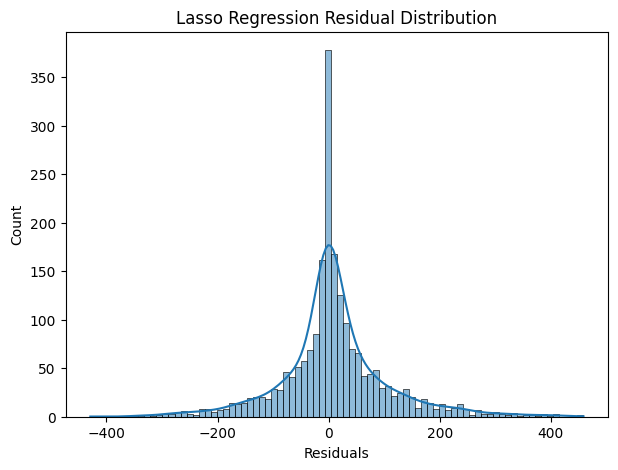

In [21]:
best_model = lasso_grid.best_estimator_
plot_model_reiduals(lasso_grid.best_estimator_, X_val, y_val, 'Lasso Regression')

### Q9. Explain why the winning model performs better.

**Ans9.**

Lasso Regression achieved the lowest validation RMSLE among all evaluated models. The model performed better because polynomial feature expansion enabled it to capture nonlinear relationships between weather, seasonal, and temporal variables. L1 regularization reduced model complexity by shrinking less informative coefficients toward zero, thereby reducing overfitting. Hyperparameter tuning identified an effective combination of polynomial degree and regularization strength. In addition, feature engineering such as cyclical transformations and target log transformation helped the model capture underlying patterns more effectively. As a result, Lasso Regression provided the best balance between predictive performance and generalization.


## <a id='section_5'>5. Reflection questions</a>

### Q10. Why does RMSLE penalize under-predictions more gently than RMSE?

**Ans:**

RMSLE computes prediction errors on a logarithmic scale rather than the original scale. This reduces the impact of large absolute errors and focuses more on relative differences between predicted and actual values. Therefore, RMSLE is generally more suitable for count prediction problems where proportional errors are more important than absolute errors.

### Q11. What are the trade-offs between model simplicity and predictive power?

**Ans:**

Simple models such as Linear Regression are easy to interpret, computationally efficient, and less prone to overfitting. However, they may fail to capture complex nonlinear relationships present in real-world data. More complex models such as Polynomial Regression can achieve better predictive performance by modeling nonlinear interactions, but they increase model complexity and the risk of overfitting. Regularization techniques such as Ridge and Lasso help balance predictive power and model simplicity.

### Q12. Why can’t Linear Regression alone capture time-of-day effects effectively?

**Ans:**

Bike rental demand follows cyclical daily patterns with peaks during commuting hours and lower demand during late-night hours. Linear Regression assumes a straight-line relationship between predictors and the target variable and therefore cannot naturally model cyclic behavior. Feature engineering techniques such as cyclical transformations (`hour_sin` and `hour_cos`) or polynomial transformations are required to effectively capture these time-of-day effects.


## Create `submission.csv` file for test set predictions using the best performing model (Lasso Regression in this case) to generate predictions for the test dataset and prepare it for submission to Kaggle

In [29]:
test_data = pd.read_csv('bike_test.csv')
print(test_data.shape)
test_data.head()

(2613, 9)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,05-06-2012 5:00,2,0,1,3,19.680000,23.48500,82,11.00140
1,19-03-2011 19:00,1,0,0,1,18.040000,21.97000,33,19.00120
2,02-04-2012 6:00,2,0,1,1,13.885038,16.24664,68,29.52646
3,13-07-2012 20:00,3,0,1,1,30.340000,33.33500,48,8.99810
4,09-11-2011 19:00,4,0,1,1,18.040000,21.97000,72,7.00150


In [30]:
## Prepare submission file 
submission_csv = test_data[['datetime']].copy()
submission_csv.head()

,datetime
0,05-06-2012 5:00
1,19-03-2011 19:00
2,02-04-2012 6:00
3,13-07-2012 20:00
4,09-11-2011 19:00


In [31]:
## Change datetime column to datetime format for feature engineering and model prediction
test_data['datetime'] = pd.to_datetime(test_data['datetime'],dayfirst=True)
test_data_processed = feature_engineering(test_data)
## occurence of weather=4 is not present in the test set, but it is present in the training set. 
## This can lead to issues during model prediction since the model was trained on data that included weather=4, 
## but the test set does not have this category. The model may not know how to handle this missing category during prediction, which could result in errors or inaccurate predictions. 
## To address this, we can check for the presence of weather=4 in the test set and if it is missing, we can add a dummy column for weather=4 with all values set to 0 to ensure consistency with the training data and allow the model to make predictions without errors.
test_data_processed['weather_4'] = 0.0
test_data_processed.head()

,holiday,workingday,atemp,humidity,windspeed,hour_sin,hour_cos,month_sin,month_cos,season_1,season_2,season_3,season_4,weather_1,weather_2,weather_3,weather_4
0,0.0,1.0,23.485001,82.0,11.001400,0.965926,2.588190e-01,1.224647e-16,-1.000000e+00,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,21.969999,33.0,19.001200,-0.965926,2.588190e-01,1.000000e+00,6.123234e-17,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,16.246639,68.0,29.526461,1.000000,6.123234e-17,8.660254e-01,-5.000000e-01,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,1.0,33.334999,48.0,8.998100,-0.866025,5.000000e-01,-5.000000e-01,-8.660254e-01,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0.0,1.0,21.969999,72.0,7.001500,-0.965926,2.588190e-01,-5.000000e-01,8.660254e-01,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [32]:
## Predicting the log of the count using the best model and then applying inverse transformation to get the predicted count values.
pred_log = best_model.predict(test_data_processed)
## Re-transforming the predicted log values back to the original count scale using the inverse of the log transformation (expm1) and ensuring that predictions are non-negative since count cannot be negative
pred_count = np.expm1(pred_log)
## Ensure predictions are non-negative since count cannot be negative
pred_count = np.maximum(pred_count, 0)

## Prepare submission CSV file with datetime and predicted count values for submission to competition platform
submission_csv['count'] = pred_count.astype(int)

submission_csv.to_csv('submission.csv', index=False)

submission_csv.head()


,datetime,count
0,05-06-2012 5:00,22
1,19-03-2011 19:00,117
2,02-04-2012 6:00,41
3,13-07-2012 20:00,466
4,09-11-2011 19:00,333


### Final Summary

- Exploratory Data Analysis revealed strong relationships between bike rental demand and temperature, weather, seasonality, and time-related features.
- Feature engineering significantly improved model performance by extracting cyclical temporal information and reducing multicollinearity.
- Five regression models were evaluated: Linear Regression, Polynomial Regression Degree 2, Polynomial Regression Degree 3, Ridge Regression, and Lasso Regression.
- Linear Regression produced the weakest performance because it could not adequately capture nonlinear relationships.
- Polynomial feature expansion substantially improved predictive performance.
- Regularized models further improved generalization by controlling model complexity.
- Lasso Regression achieved the best validation RMSLE and was selected as the final model.
- Residual analysis showed that the final model produced relatively unbiased predictions and generalized well on unseen data.
